In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

27-Jan-26 12:48:32 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


## load layout from file, and plot to check

In [2]:
layout1 = pd.read_csv("260119_ARMC5mAC_TotalPhospho.csv")

In [3]:
layout1.columns.tolist()

['WELL', 'CELL', 'DRUG', 'DRUG TIME HOURS', 'PRIMARY', 'SECONDARY']

In [4]:
layout1['ROW'] = [x[:1] for x in layout1['WELL']]
layout1['COLUMN'] = [x[1:] for x in layout1['WELL']]

In [5]:
layout_check = layout1

layout_check['CELL VALS'] = layout_check['CELL'].map(
    dict(zip(layout1['CELL'].unique().tolist(), range(len(layout1['CELL'].unique().tolist())))))

layout_check['DRUG VALS'] = layout_check['DRUG'].map(
    dict(zip(layout1['DRUG'].unique().tolist(), range(len(layout1['DRUG'].unique().tolist())))))

layout_check['TIME VALS'] = layout_check['DRUG TIME HOURS'].map(
    dict(zip(layout1['DRUG TIME HOURS'].unique().tolist(), range(len(layout1['DRUG TIME HOURS'].unique().tolist())))))

<Axes: xlabel='COLUMN', ylabel='ROW'>

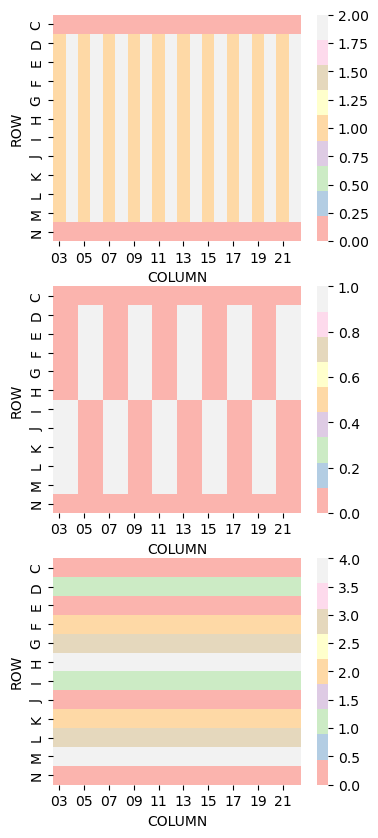

In [6]:
f, a = plt.subplots(nrows = 3, figsize = (4,10))

heat = layout_check.pivot(index = 'ROW', columns = 'COLUMN', values = 'CELL VALS')
sns.heatmap(heat, cmap = 'Pastel1', ax = a[0])

heat2 = layout_check.pivot(index = 'ROW', columns = 'COLUMN', values = 'DRUG VALS')
sns.heatmap(heat2, cmap = 'Pastel1', ax = a[1])

heat3 = layout_check.pivot(index = 'ROW', columns = 'COLUMN', values = 'TIME VALS')
sns.heatmap(heat3, cmap = 'Pastel1', ax = a[2])

## load quantification files from relevant directories, and assemble into data frames

In [48]:
quantification_directory_1 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260119_ARMC5mAC_TotalPhospho/20260123_205850_903/QUANTIFICATION")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))
len(quantification_files_1)

960

In [49]:
Path(quantification_files_1[100]).stem, Path(quantification_files_1[100]).stem[4:7],Path(quantification_files_1[100]).stem[40:44]

('WellM17_Channel640,405,Mono,488_Seq0214_0002.ome', 'M17', '0002')

In [50]:
qdfs = list()


for f in tqdm(quantification_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[40:44] for f in files]
quantifcation_percell_1['fov'] = fovs

100%|██████████| 960/960 [00:19<00:00, 48.09it/s]


In [51]:
Intensities = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "IF_647_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_640'],
    "GFP_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_405'],
    "NucleusArea" : quantifcation_percell_1['Nuclei_area']
})

In [55]:
CountsByWell = Intensities.groupby('WELL').count()['NucleusArea'].reset_index().merge(layout1, how = 'left')
CountsByWell.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)

In [53]:
IntensitiesByWell = Intensities.groupby('WELL').mean().reset_index().merge(layout1, how = 'left')

<Axes: xlabel='COLUMN', ylabel='ROW'>

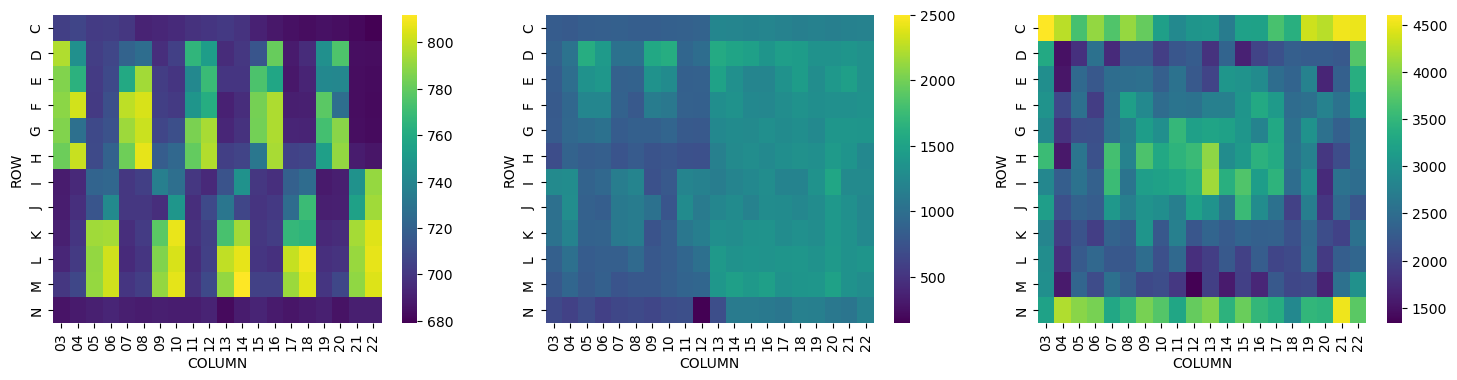

In [57]:
f, a = plt.subplots(ncols = 3, figsize = (18,4))

heat = IntensitiesByWell.pivot(index = 'ROW', columns = 'COLUMN', values = 'GFP_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[0])

heat = IntensitiesByWell.pivot(index = 'ROW', columns = 'COLUMN', values = 'IF_647_Intensity')
sns.heatmap(heat, cmap = 'viridis', ax = a[1], vmax = 2500)

heat = CountsByWell.pivot(index = 'ROW', columns = 'COLUMN', values = 'TotalNumberCells')
sns.heatmap(heat, cmap = 'viridis', ax = a[2])

## plotting raw data by cell type and treatment

In [82]:
IntensitiesByWell = IntensitiesByWell.query('ROW != "I" & ROW != "J"') 

In [59]:
IntensitiesByWell.CELL.unique(),IntensitiesByWell.PRIMARY.unique(),IntensitiesByWell.SECONDARY.unique(),

(array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object),
 array(['Total Pol II F12', 'pSer2 Pol II 3E10'], dtype=object),
 array(['Goat anti-mouse Alexa647', 'Goat anti-rat Alexa647'], dtype=object))

In [62]:
IntensitiesByWell.query('WELL == "N12"').IF_647_Intensity.mean()

146.90286314709655

In [63]:
co = ['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
       'HCT116 OsTIRF74G ARMC5mAC Clone 5F9']

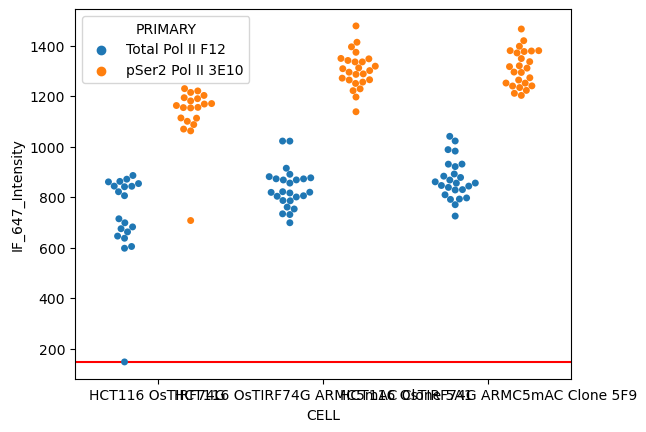

In [64]:
sns.swarmplot(IntensitiesByWell.query('DRUG  == "Vehicle" | DRUG  == "No addition"'),
            x = 'CELL', order = co,
              hue = 'PRIMARY', dodge = True,
            y = 'IF_647_Intensity')

plt.axhline(146.90286314709655, color = 'red')

<Axes: xlabel='CELL', ylabel='GFP_Intensity'>

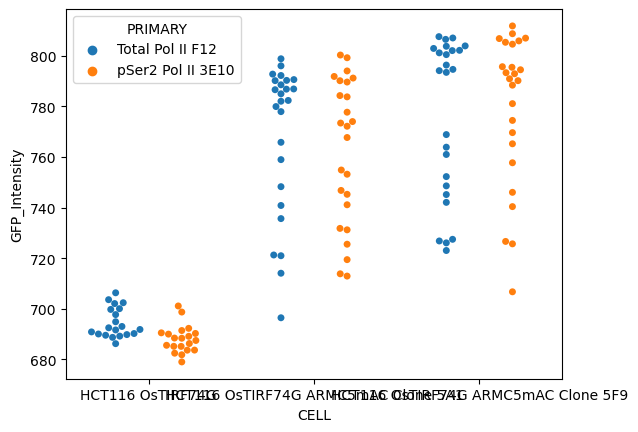

In [65]:
sns.swarmplot(IntensitiesByWell.query('DRUG  == "Vehicle" | DRUG  == "No addition"'),
            x = 'CELL', order = co,
              hue = 'PRIMARY', dodge = True,
            y = 'GFP_Intensity')

In [84]:
IntensitiesByWellAdds = IntensitiesByWell.query('DRUG != "No addition"')
IntensitiesByWellAdds["TIME_HOURS"] = IntensitiesByWellAdds["DRUG TIME HOURS"].astype(int)

In [67]:
IntensitiesByWellAdds.DRUG.unique()

array(['Vehicle', '10 µM 5PhIAA'], dtype=object)

In [68]:
ho = IntensitiesByWellAdds.DRUG.unique()

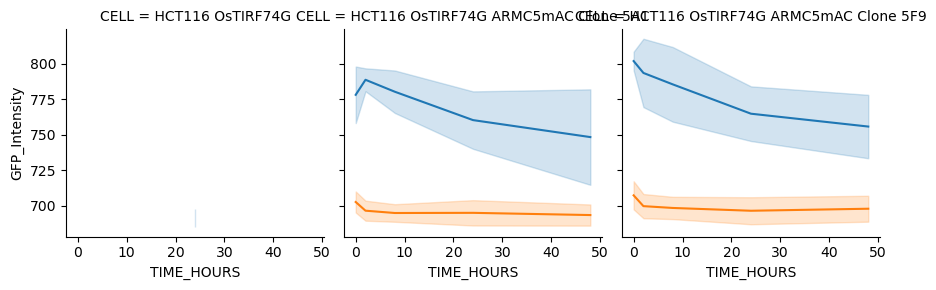

In [85]:
g = sns.FacetGrid(IntensitiesByWellAdds, col = 'CELL', col_order = co)

g.map_dataframe(sns.lineplot, x = 'TIME_HOURS', hue = 'DRUG', hue_order = ho, y = 'GFP_Intensity', errorbar = 'sd')

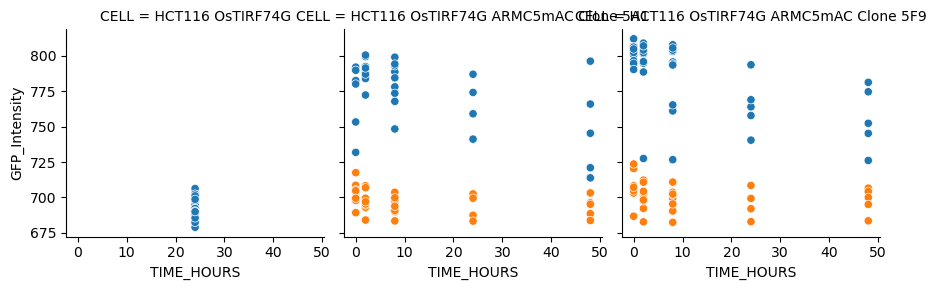

In [86]:
g = sns.FacetGrid(IntensitiesByWellAdds, col = 'CELL', col_order = co)

g.map_dataframe(sns.scatterplot, x = 'TIME_HOURS', hue = 'DRUG', hue_order = ho, y = 'GFP_Intensity')

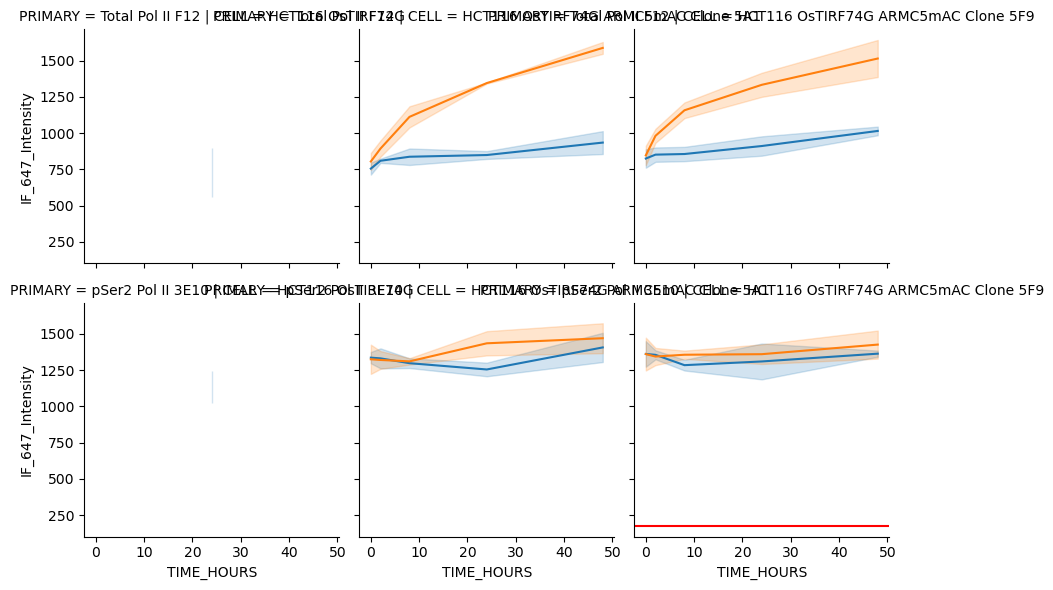

In [87]:
g = sns.FacetGrid(IntensitiesByWellAdds.query('PRIMARY != "No primary"'), col = 'CELL', col_order = co, row = 'PRIMARY')

g.map_dataframe(sns.lineplot, x = 'TIME_HOURS', hue = 'DRUG', hue_order = ho, y = 'IF_647_Intensity', errorbar = 'sd')

plt.axhline(174.75019938898404, color = 'red')

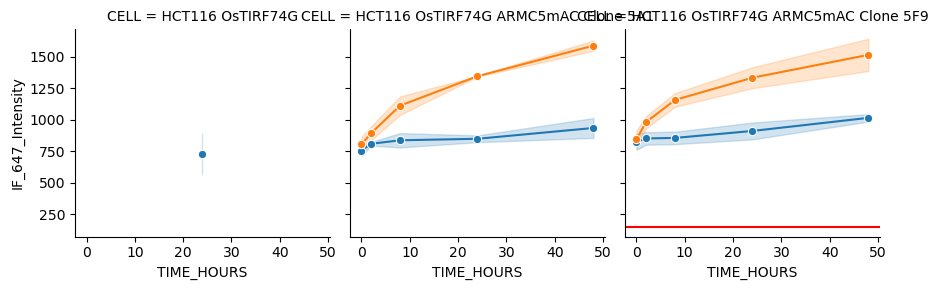

In [88]:
g = sns.FacetGrid(IntensitiesByWellAdds.query('PRIMARY != "pSer2 Pol II 3E10"'), col = 'CELL', col_order = co)

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HOURS',
                hue = 'DRUG', hue_order = ho, 
                y = 'IF_647_Intensity',
                marker = 'o',
                errorbar = 'sd')

plt.axhline(146.90286314709655, color = 'red')

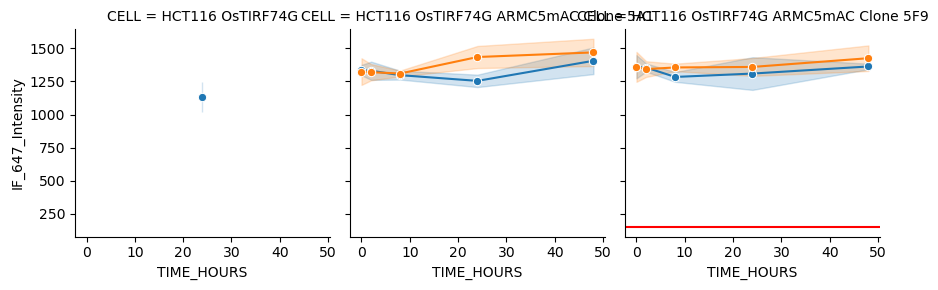

In [89]:
g = sns.FacetGrid(IntensitiesByWellAdds.query('PRIMARY == "pSer2 Pol II 3E10"'), col = 'CELL', col_order = co)

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HOURS',
                hue = 'DRUG', hue_order = ho, 
                y = 'IF_647_Intensity',
                marker = 'o',
                errorbar = 'sd')

plt.axhline(146.90286314709655, color = 'red')

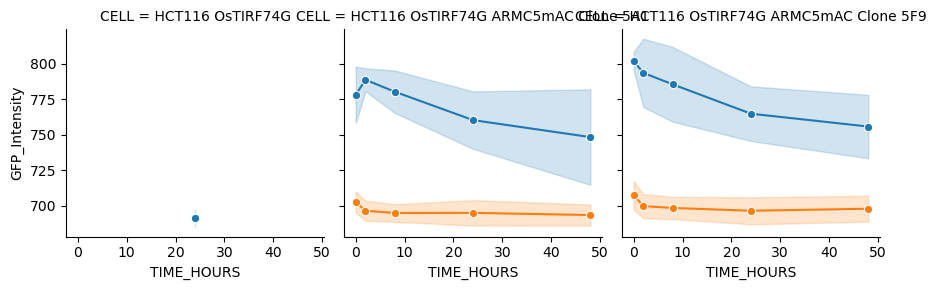

In [90]:
g = sns.FacetGrid(IntensitiesByWellAdds, col = 'CELL', col_order = co)

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HOURS',
                hue = 'DRUG', hue_order = ho, 
                y = 'GFP_Intensity',
                marker = 'o',
                errorbar = 'sd')

#plt.axhline(146.90286314709655, color = 'red')

(600.0, 800.0)

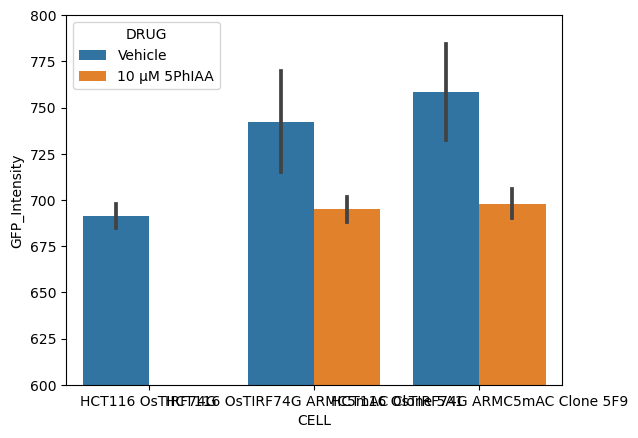

In [76]:
sns.barplot(IntensitiesByWellAdds.query('TIME_HOURS == 24'),
            x = 'CELL', order = co,
            hue = 'DRUG', hue_order = ho,
            y = 'GFP_Intensity',
           errorbar =  'sd')
plt.ylim(600,800)